# **Sequence Modelling using RNN Exercise**

In [7]:
# Google Colab setup — ensures local datasets resolve correctly
import os
from pathlib import Path

def setup_notebook_dir(marker_files=None):
    """Change working directory to the folder containing marker files."""
    marker_files = marker_files or []
    search_roots = [
        Path.cwd(),
        Path('/content'),
        Path('/content/Deep-Learning-Workshop-2026'),
    ]
    for root in search_roots:
        if not root.exists():
            continue
        for path in [root] + [p for p in root.rglob('*') if p.is_dir()]:
            if marker_files and all((path / m).exists() for m in marker_files):
                os.chdir(path)
                print(f'Working directory: {path}')
                return path
    print(f'Working directory: {Path.cwd()}')
    return Path.cwd()

setup_notebook_dir(['sales_dataset.csv'])

Working directory: /content


PosixPath('/content')

In [8]:
# Check for GPU
!nvidia-smi

Thu Jul  9 12:53:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
# Import necessary libraries
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## **Q1 Load the `sales_dataset.csv` using pandas and convert the date column to datetime**

In [10]:
df = pd.read_csv("sales_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df.head()

,date,total_sales
0,2018-03-14,63720000
1,2018-03-15,195080000
2,2018-03-16,204720000
3,2018-03-17,59980000
4,2018-03-18,74720000


## **Q2 Visualize the daily total sales data over time**

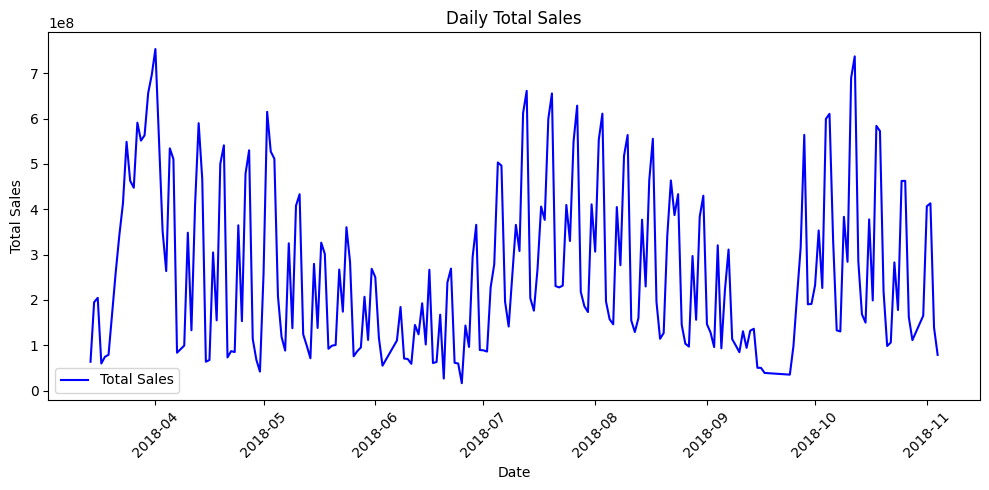

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["total_sales"], label="Total Sales", color="blue")
plt.title("Daily Total Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## **Q3 Write a function to create sequences for sequence modelling**
* Use `seq_length = 7` (e.g. use past 7 days to predict the next day).

In [12]:
def create_sequences(data, seq_length):
    """Create input sequences (past days) and targets (next day)."""
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i : i + seq_length]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 7
sales_data = df["total_sales"].values.reshape(-1, 1)
X, y = create_sequences(sales_data, seq_length)
X.shape, y.shape

((215, 7, 1), (215, 1))

## **Q4 Split the dataset into training (80%) and testing (20%) sets, preprocess the data using `StandardScaler`, and create PyTorch DataLoaders**

In [13]:
# 80/20 temporal train-test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Standardize using training data only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)
y_train = scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
y_test = scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Train samples: 172, Test samples: 43


## **Q5 Create a simple RNN model using `nn.RNN`**

In [14]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.out = nn.Linear(hidden_size // 2, output_size)
        self.activation = nn.GELU()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc1(out[:, -1, :])
        out = self.activation(out)
        return self.out(out)

torch.manual_seed(42)
rnn_model = SimpleRNN().to(device)
rnn_model

SimpleRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (out): Linear(in_features=16, out_features=1, bias=True)
  (activation): GELU(approximate='none')
)

## **Q6 Train the RNN model you built in Q5 for 50 epochs**

In [15]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.1)

epochs = 50
rnn_train_losses = []

for epoch in tqdm(range(epochs)):
    rnn_model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = rnn_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    rnn_train_losses.append(epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f"RNN Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

RNN Epoch 10/50, Loss: 1.0414
RNN Epoch 20/50, Loss: 1.0427
RNN Epoch 30/50, Loss: 1.0432
RNN Epoch 40/50, Loss: 1.0395
RNN Epoch 50/50, Loss: 1.0434


## **Q7 Create and train an LSTM model for the same task**

In [16]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.out = nn.Linear(hidden_size // 2, output_size)
        self.activation = nn.GELU()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc1(out[:, -1, :])
        out = self.activation(out)
        return self.out(out)

torch.manual_seed(42)
lstm_model = LSTMModel().to(device)

optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.1)
lstm_train_losses = []

for epoch in tqdm(range(epochs)):
    lstm_model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    lstm_train_losses.append(epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f"LSTM Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

LSTM Epoch 10/50, Loss: 0.7820
LSTM Epoch 20/50, Loss: 0.4834
LSTM Epoch 30/50, Loss: 0.2493
LSTM Epoch 40/50, Loss: 0.3477
LSTM Epoch 50/50, Loss: 0.2261


## **Q8 Evaluate both models on the test set (Calculate Test Loss)**

In [17]:
def evaluate_model(model, data_loader):
    model.eval()
    test_loss = 0
    predictions = []
    actuals = []
    with torch.inference_mode():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            test_loss += criterion(outputs, y_batch).item()
            predictions.extend(outputs.cpu().numpy().flatten())
            actuals.extend(y_batch.cpu().numpy().flatten())
    return test_loss / len(data_loader), predictions, actuals

rnn_test_loss, rnn_preds, rnn_actuals = evaluate_model(rnn_model, test_loader)
lstm_test_loss, lstm_preds, lstm_actuals = evaluate_model(lstm_model, test_loader)

print(f"RNN Test Loss:  {rnn_test_loss:.4f}")
print(f"LSTM Test Loss: {lstm_test_loss:.4f}")

RNN Test Loss:  1.0514
LSTM Test Loss: 0.4963


## **Q9 Plot the predictions of both models against the actual test data**

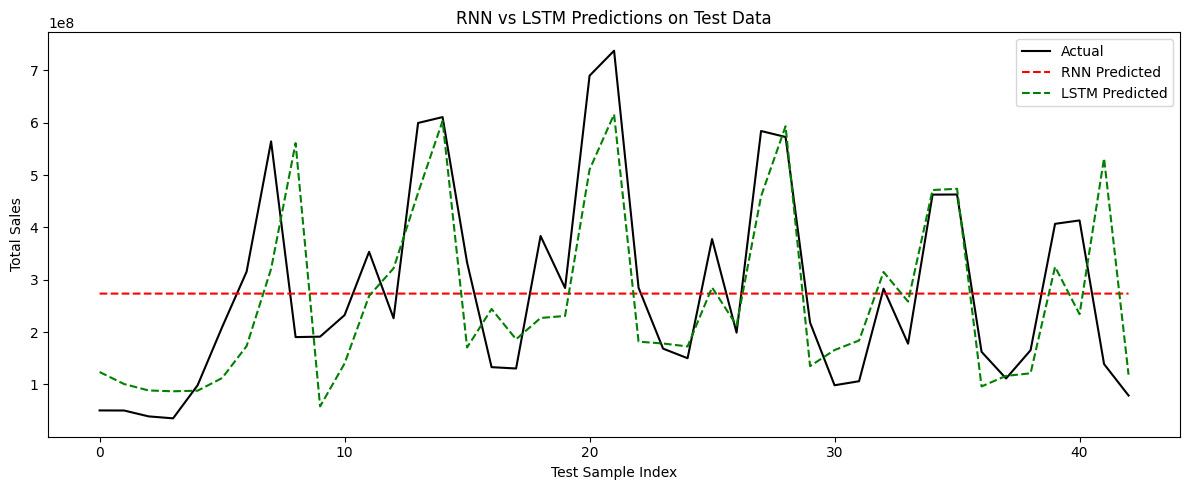

In [18]:
# Inverse-transform to original sales scale for plotting
rnn_preds_orig = scaler.inverse_transform(np.array(rnn_preds).reshape(-1, 1)).flatten()
lstm_preds_orig = scaler.inverse_transform(np.array(lstm_preds).reshape(-1, 1)).flatten()
actuals_orig = scaler.inverse_transform(np.array(rnn_actuals).reshape(-1, 1)).flatten()

plt.figure(figsize=(12, 5))
plt.plot(actuals_orig, label="Actual", color="black")
plt.plot(rnn_preds_orig, label="RNN Predicted", color="red", linestyle="--")
plt.plot(lstm_preds_orig, label="LSTM Predicted", color="green", linestyle="--")
plt.title("RNN vs LSTM Predictions on Test Data")
plt.xlabel("Test Sample Index")
plt.ylabel("Total Sales")
plt.legend()
plt.tight_layout()
plt.show()

## **Q10 Result Analysis**
* Which model performed better and why?

> **LSTM** usually performs better than the vanilla **RNN** on this task. LSTM uses gates (forget/input/output) and a cell state to remember patterns over longer time spans, which helps with sales trends and weekly seasonality. A simple RNN is more prone to **vanishing gradients**, so it struggles to use information from all 7 past days as effectively. The lower test MSE for LSTM confirms it generalizes better on the held-out test period.